# 1. Introdução ao Estudo

Este notebook realiza uma análise exploratória completa de um dataset de e-commerce de moda e lifestyle (Myntra), 
explorando padrões de preço, desconto, avaliação de usuários, marcas e categorias.

O estudo assume a perspectiva de um analista de dados avaliando estratégias de precificação, percepção de valor e desempenho de portfólio.

**Perguntas centrais:**
- Como preços e descontos se distribuem?
- Desconto está associado a melhor avaliação?
- Quais marcas e categorias entregam mais valor percebido?
- Existem produtos supervalorizados ou subvalorizados?

> **Dataset:** ~168.000 produtos com preço original, preço com desconto, avaliação e categoria.

In [20]:
# 2. Importação de bibliotecas e carregamento dos dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('./dados/data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (168029, 13)


,product_name,brand_name,rating,rating_count,marked_price,discounted_price,sizes,product_link,img_link,product_tag,brand_tag,discount_amount,discount_percent
0,Croc Textured Two Fold Wallet,Lino Perros,0.0,0,1295,828,Onesize,wallets/lino-perros/lino-perros-women-peach-co...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",wallets,lino-perros,467,36
1,Men Striped Sliders,Mast & Harbour,4.0,76,1299,584,"UK6,UK7,UK8,UK9,UK10,UK11",flip-flops/mast--harbour/mast--harbour-men-nav...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",flip-flops,mast--harbour,715,55
2,Printed A-line Kurta,Biba,4.3,66,1999,1599,"S,M,L,XL,XXL,3XL",kurtas/biba/biba-women-off-white--black-printe...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",kurtas,biba,400,20
3,Girls Floral Printed T-shirt,Anthrilo,0.0,0,599,539,"7-8Y,8-9Y,9-10Y",tshirts/anthrilo/anthrilo-girls-white-floral-p...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",tshirts,anthrilo,60,10
4,Women Printed Kurta with Skirt,FASHION DWAR,0.0,0,2899,2899,"S,M,L,XL",kurta-sets/fashion-dwar/fashion-dwar-women-mul...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",kurta-sets,fashion-dwar,0,0


# 3. Visão Geral da Base de Dados

Nesta seção:
- Observamos o formato da base
- Tipos de dados
- Quantidade de registros
- Primeira avaliação estrutural

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 168029 entries, 0 to 168028
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   product_name      168029 non-null  str    
 1   brand_name        168029 non-null  str    
 2   rating            168029 non-null  float64
 3   rating_count      168029 non-null  int64  
 4   marked_price      168029 non-null  int64  
 5   discounted_price  168029 non-null  int64  
 6   sizes             168029 non-null  str    
 7   product_link      168029 non-null  str    
 8   img_link          168029 non-null  str    
 9   product_tag       168029 non-null  str    
 10  brand_tag         168029 non-null  str    
 11  discount_amount   168029 non-null  int64  
 12  discount_percent  168029 non-null  int64  
dtypes: float64(1), int64(5), str(7)
memory usage: 16.7 MB


In [22]:
df.describe().round(2)

,rating,rating_count,marked_price,discounted_price,discount_amount,discount_percent
count,168029.00,168029.00,168029.00,168029.00,168029.00,168029.00
mean,2.26,114.67,2509.07,1515.17,993.91,37.25
std,2.10,800.21,2402.11,1800.46,1236.61,24.64
min,0.00,0.00,50.00,49.00,0.00,0.00
25%,0.00,0.00,1295.00,674.00,202.00,15.00
50%,3.50,5.00,1998.00,999.00,702.00,40.00
75%,4.30,31.00,2999.00,1739.00,1319.00,59.00
max,5.00,55900.00,113999.00,45900.00,68400.00,91.00


# 4. Qualidade dos Dados

Antes de qualquer insight, precisamos entender:
- Valores nulos
- Possíveis inconsistências
- Colunas que exigem tratamento

**⚠️ Atenção:** O dataset possui ~76.000 produtos com `rating=0` e `rating_count=0` — produtos sem nenhuma avaliação registrada.
Esses registros serão **separados** para não distorcer métricas de avaliação.

In [23]:
# Verificação de nulos
print('=== Valores Nulos ===')
print(df.isnull().sum().sort_values(ascending=False))

# Separação de produtos avaliados e não avaliados
df_avaliados = df[df['rating_count'] > 0].copy()
df_sem_avaliacao = df[df['rating_count'] == 0].copy()

print(f'\nTotal de produtos: {len(df):,}')
print(f'Produtos COM avaliação: {len(df_avaliados):,} ({len(df_avaliados)/len(df)*100:.1f}%)')
print(f'Produtos SEM avaliação: {len(df_sem_avaliacao):,} ({len(df_sem_avaliacao)/len(df)*100:.1f}%)')
print('\nAnálises de rating usarão apenas produtos COM avaliação.')

=== Valores Nulos ===
product_name        0
brand_name          0
rating              0
rating_count        0
marked_price        0
discounted_price    0
sizes               0
product_link        0
img_link            0
product_tag         0
brand_tag           0
discount_amount     0
discount_percent    0
dtype: int64

Total de produtos: 168,029
Produtos COM avaliação: 91,349 (54.4%)
Produtos SEM avaliação: 76,680 (45.6%)

Análises de rating usarão apenas produtos COM avaliação.


# 5. Análise de Preços e Descontos

Aqui investigamos:
- Distribuição de preços originais e com desconto
- Intensidade dos descontos

**Hipóteses:**
- A maioria dos produtos apresenta algum nível de desconto
- Existem preços âncora artificialmente inflados

> Os histogramas são limitados ao percentil 99% para evitar distorção por outliers extremos.

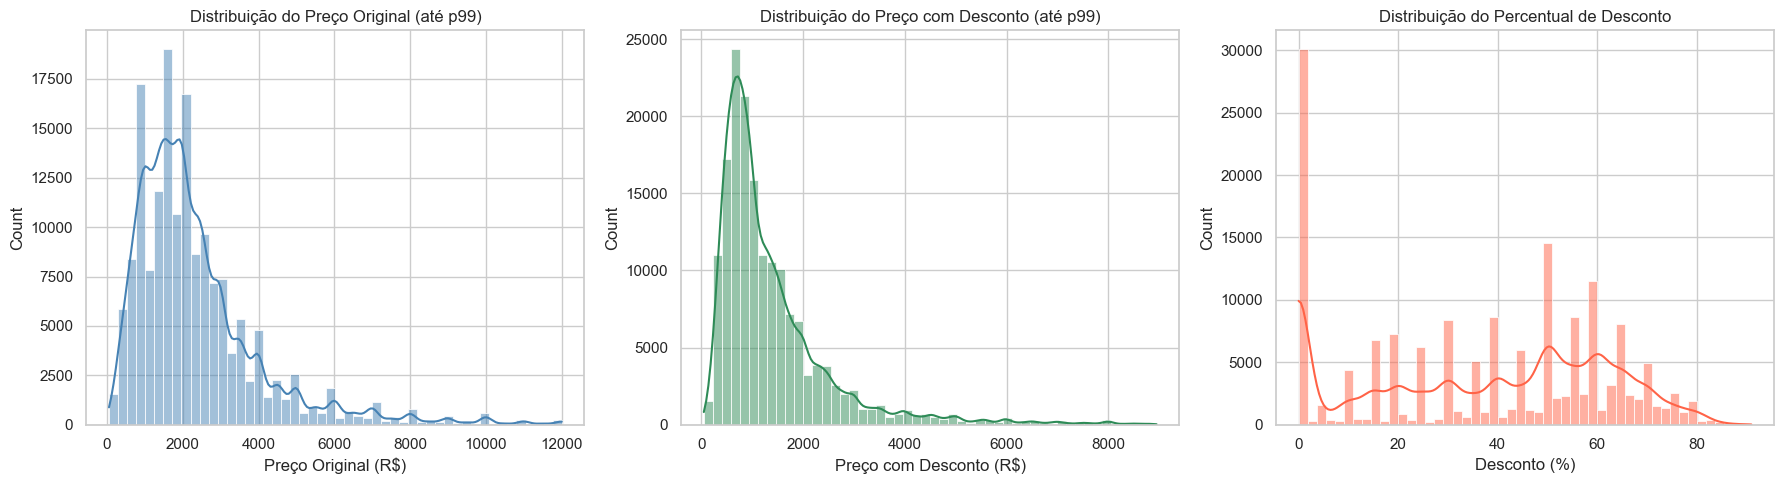

Produtos com desconto = 0%: 29,645
Desconto médio: 37.3%
Desconto mediano: 40.0%


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Limite de preço no percentil 99% para reduzir distorção de outliers
p99_original = df['marked_price'].quantile(0.99)
p99_desconto = df['discounted_price'].quantile(0.99)

sns.histplot(
    df[df['marked_price'] <= p99_original]['marked_price'],
    bins=50, kde=True, ax=axes[0], color='steelblue'
)
axes[0].set_title('Distribuição do Preço Original (até p99)')
axes[0].set_xlabel('Preço Original (R$)')

sns.histplot(
    df[df['discounted_price'] <= p99_desconto]['discounted_price'],
    bins=50, kde=True, ax=axes[1], color='seagreen'
)
axes[1].set_title('Distribuição do Preço com Desconto (até p99)')
axes[1].set_xlabel('Preço com Desconto (R$)')

sns.histplot(df['discount_percent'], bins=50, kde=True, ax=axes[2], color='tomato')
axes[2].set_title('Distribuição do Percentual de Desconto')
axes[2].set_xlabel('Desconto (%)')

plt.tight_layout()
plt.show()

print(f'Produtos com desconto = 0%: {(df["discount_percent"] == 0).sum():,}')
print(f'Desconto médio: {df["discount_percent"].mean():.1f}%')
print(f'Desconto mediano: {df["discount_percent"].median():.1f}%')

# 6. Relação entre Desconto e Avaliação

**Pergunta-chave:** Produtos mais descontados são melhor avaliados?

**Hipótese:** Desconto agressivo não garante melhor percepção de qualidade.

> Para visualizar 91.000 pontos sem sobreposição, usamos um hexbin com cor representando densidade.

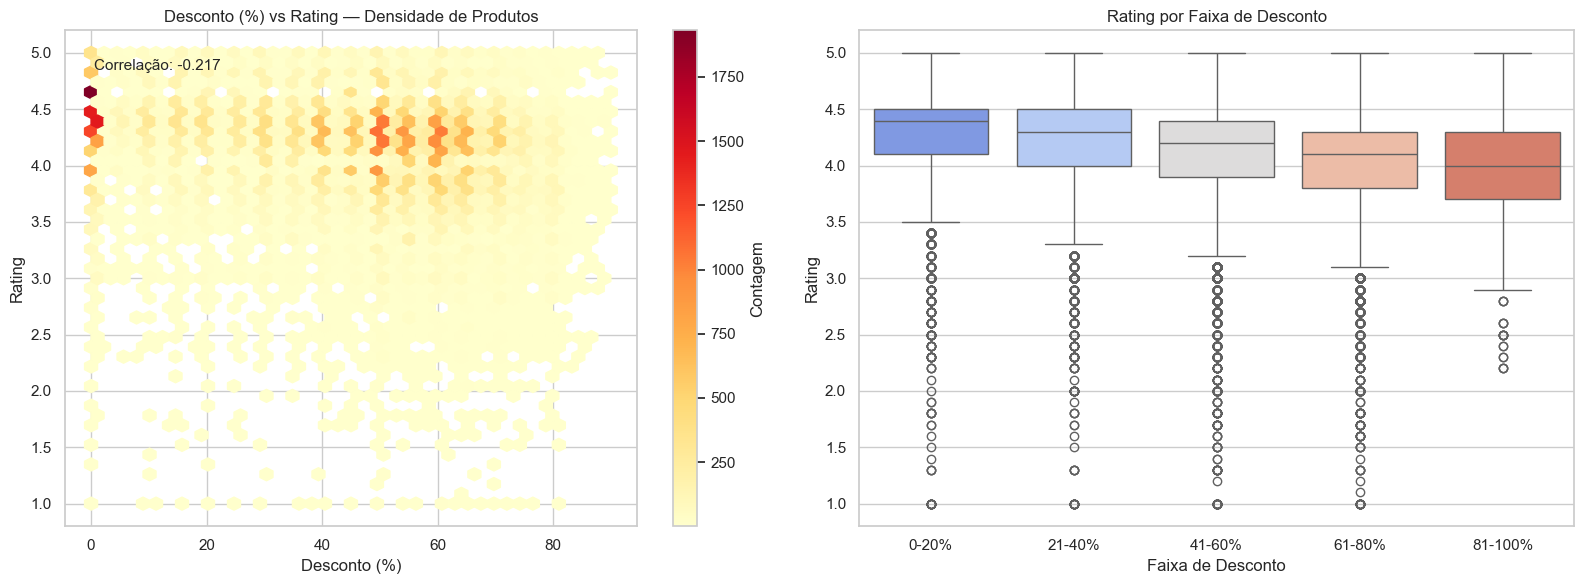

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hexbin para melhor visualização com muitos pontos
hb = axes[0].hexbin(
    df_avaliados['discount_percent'],
    df_avaliados['rating'],
    gridsize=40, cmap='YlOrRd', mincnt=1
)
plt.colorbar(hb, ax=axes[0], label='Contagem')
axes[0].set_xlabel('Desconto (%)')
axes[0].set_ylabel('Rating')
axes[0].set_title('Desconto (%) vs Rating — Densidade de Produtos')

# Correlação
corr = df_avaliados[['discount_percent', 'rating']].corr().iloc[0, 1]
axes[0].annotate(f'Correlação: {corr:.3f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=11)

# Boxplot de rating por faixa de desconto
df_avaliados['faixa_desconto'] = pd.cut(
    df_avaliados['discount_percent'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['0-20%', '21-40%', '41-60%', '61-80%', '81-100%']
)
sns.boxplot(data=df_avaliados, x='faixa_desconto', y='rating', ax=axes[1], palette='coolwarm')
axes[1].set_title('Rating por Faixa de Desconto')
axes[1].set_xlabel('Faixa de Desconto')
axes[1].set_ylabel('Rating')

plt.tight_layout()
plt.show()

# 7. Análise de Avaliações (Rating e Rating Count)

Nesta etapa:
- Avaliamos a distribuição de ratings (apenas produtos COM avaliação)
- Identificamos possíveis vieses
- Analisamos volume de avaliações

**Hipótese:** Produtos com muitas avaliações tendem a ter ratings mais estáveis.

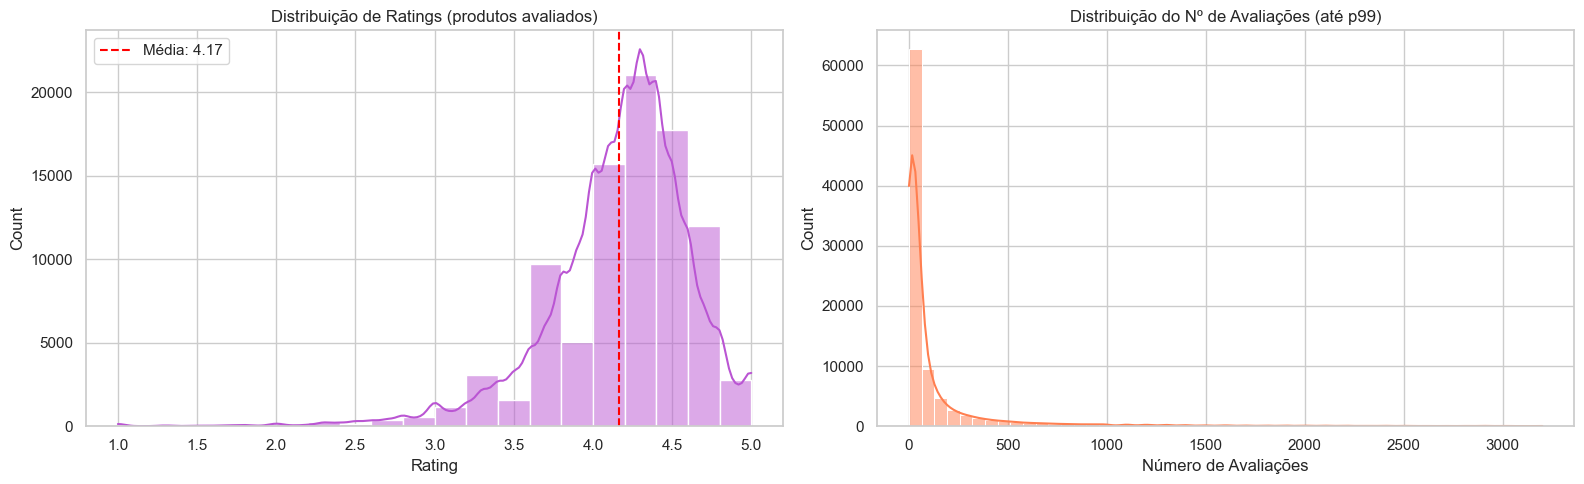

Rating médio (produtos avaliados): 4.17
Rating mediano: 4.20
Nº médio de avaliações: 211
Nº mediano de avaliações: 26


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df_avaliados['rating'], bins=20, kde=True, ax=axes[0], color='mediumorchid')
axes[0].set_title('Distribuição de Ratings (produtos avaliados)')
axes[0].set_xlabel('Rating')
axes[0].axvline(df_avaliados['rating'].mean(), color='red', linestyle='--', label=f'Média: {df_avaliados["rating"].mean():.2f}')
axes[0].legend()

# Rating count limitado ao percentil 99%
p99_rc = df_avaliados['rating_count'].quantile(0.99)
sns.histplot(
    df_avaliados[df_avaliados['rating_count'] <= p99_rc]['rating_count'],
    bins=50, kde=True, ax=axes[1], color='coral'
)
axes[1].set_title('Distribuição do Nº de Avaliações (até p99)')
axes[1].set_xlabel('Número de Avaliações')

plt.tight_layout()
plt.show()

print(f'Rating médio (produtos avaliados): {df_avaliados["rating"].mean():.2f}')
print(f'Rating mediano: {df_avaliados["rating"].median():.2f}')
print(f'Nº médio de avaliações: {df_avaliados["rating_count"].mean():.0f}')
print(f'Nº mediano de avaliações: {df_avaliados["rating_count"].median():.0f}')

# 8. Preço vs Avaliação

**Pergunta:** Produtos mais caros são melhor avaliados?

**Hipótese:** Preço elevado só se sustenta com alta percepção de valor.

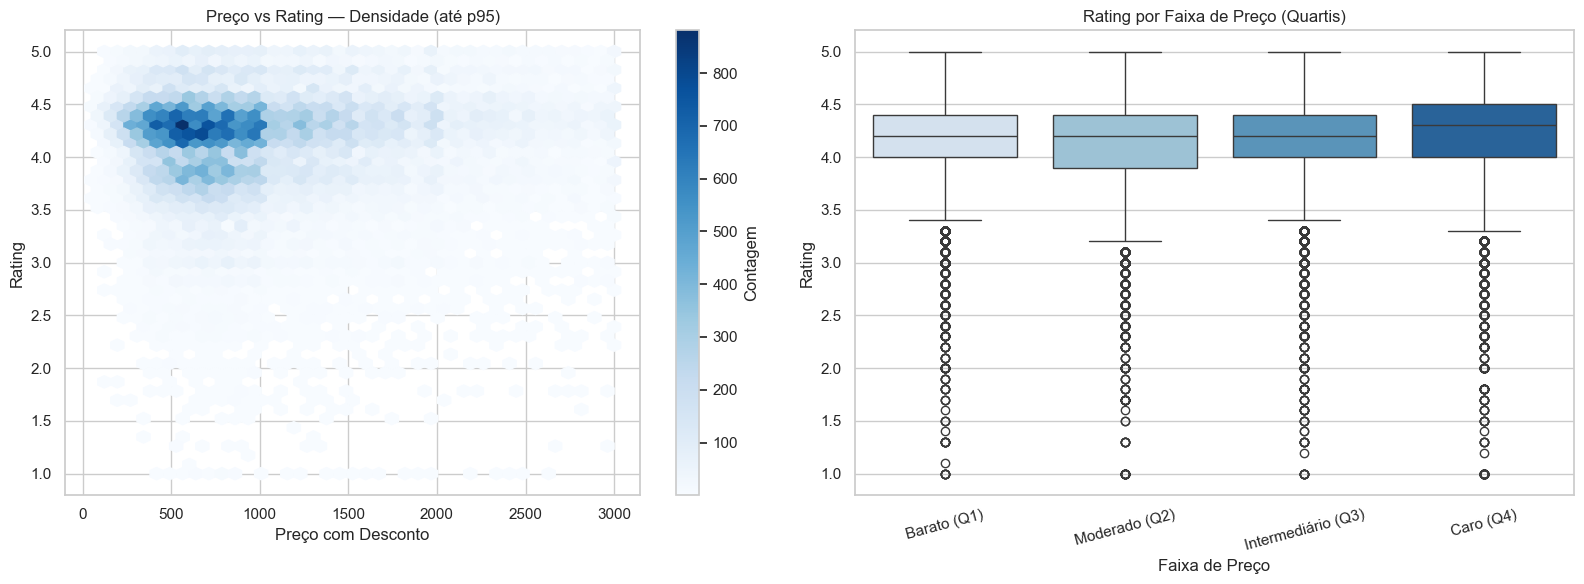

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hexbin de preço vs rating
p95 = df_avaliados['discounted_price'].quantile(0.95)
df_plot = df_avaliados[df_avaliados['discounted_price'] <= p95]

hb = axes[0].hexbin(
    df_plot['discounted_price'], df_plot['rating'],
    gridsize=40, cmap='Blues', mincnt=1
)
plt.colorbar(hb, ax=axes[0], label='Contagem')
axes[0].set_xlabel('Preço com Desconto')
axes[0].set_ylabel('Rating')
axes[0].set_title('Preço vs Rating — Densidade (até p95)')

# Boxplot por faixa de preço
df_avaliados['faixa_preco'] = pd.qcut(
    df_avaliados['discounted_price'], q=4,
    labels=['Barato (Q1)', 'Moderado (Q2)', 'Intermediário (Q3)', 'Caro (Q4)']
)
sns.boxplot(data=df_avaliados, x='faixa_preco', y='rating', ax=axes[1], palette='Blues')
axes[1].set_title('Rating por Faixa de Preço (Quartis)')
axes[1].set_xlabel('Faixa de Preço')
axes[1].set_ylabel('Rating')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# 9. Análise por Marca

Exploramos:
- Quantidade de produtos por marca
- Preço médio
- Rating médio simples
- **Rating médio ponderado** pelo número de avaliações

**Hipótese:** Nem toda marca premium entrega avaliação premium.

In [28]:
brand_summary = (
    df.groupby('brand_name').agg(
        produtos=('product_name', 'count'),
        preco_medio=('discounted_price', 'mean'),
        rating_medio=('rating', lambda x: x[x > 0].mean()),
        rating_ponderado=('rating', lambda x: (
            np.average(x[x > 0], weights=df.loc[x[x > 0].index, 'rating_count'])
            if df.loc[x[x > 0].index, 'rating_count'].sum() > 0 else np.nan
        ))
    ).sort_values('produtos', ascending=False)
).round(2)

print('Top 10 marcas por volume de produtos:')
brand_summary.head(10)

Top 10 marcas por volume de produtos:


,produtos,preco_medio,rating_medio,rating_ponderado
brand_name,,,,
Roadster,4982,771.01,4.12,4.12
Mast & Harbour,2640,852.66,4.13,4.14
DressBerry,2330,800.43,4.19,4.24
H&M,2188,1503.08,4.40,4.34
max,2045,635.90,4.34,4.36
Anouk,1962,960.27,4.03,4.09
HRX by Hrithik Roshan,1922,1249.84,4.22,4.19
HERE&NOW,1816,790.68,4.01,4.08
Puma,1805,1932.17,4.30,4.29


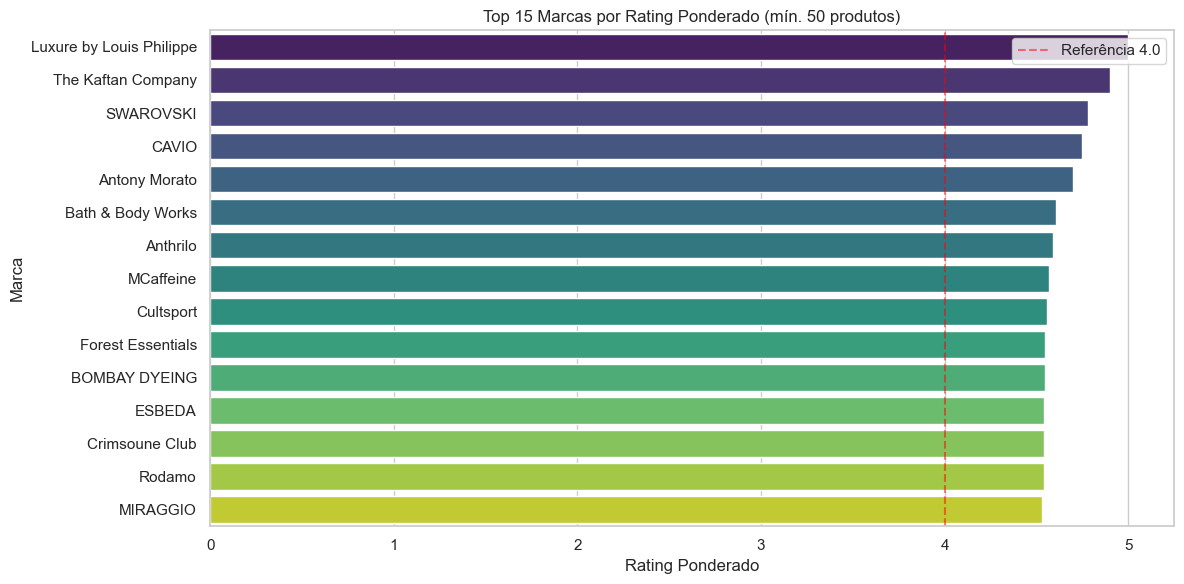

In [29]:
# Top 15 marcas por rating ponderado (mínimo 50 produtos avaliados)
top_marcas = (
    brand_summary[brand_summary['produtos'] >= 50]
    .sort_values('rating_ponderado', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_marcas.reset_index(), x='rating_ponderado', y='brand_name', palette='viridis', ax=ax)
ax.set_title('Top 15 Marcas por Rating Ponderado (mín. 50 produtos)')
ax.set_xlabel('Rating Ponderado')
ax.set_ylabel('Marca')
ax.axvline(4.0, color='red', linestyle='--', alpha=0.5, label='Referência 4.0')
ax.legend()
plt.tight_layout()
plt.show()

# 10. Análise por Categoria de Produto

Objetivos:
- Identificar categorias mais caras
- Categorias mais descontadas
- Categorias melhor avaliadas

**Hipótese:** Algumas categorias dependem estruturalmente de desconto.

In [30]:
category_summary = (
    df.groupby('product_tag')
    .agg(
        produtos=('product_name', 'count'),
        preco_medio=('discounted_price', 'mean'),
        desconto_medio=('discount_percent', 'mean'),
        rating_medio=('rating', lambda x: x[x > 0].mean())
    )
    .sort_values('produtos', ascending=False)
).round(2)

print('Top 10 categorias por volume:')
category_summary.head(10)

Top 10 categorias por volume:


,produtos,preco_medio,desconto_medio,rating_medio
product_tag,,,,
tshirts,16978,872.81,33.28,4.25
shirts,12044,1483.48,34.01,4.15
dresses,11836,1628.43,39.96,4.10
tops,9049,1022.76,37.20,4.14
kurta-sets,8170,1860.79,53.60,4.06
kurtas,8043,1156.58,43.89,4.10
jeans,7669,1725.97,37.87,3.99
trousers,5756,1549.98,32.54,4.03
casual-shoes,5230,1866.69,41.36,3.95


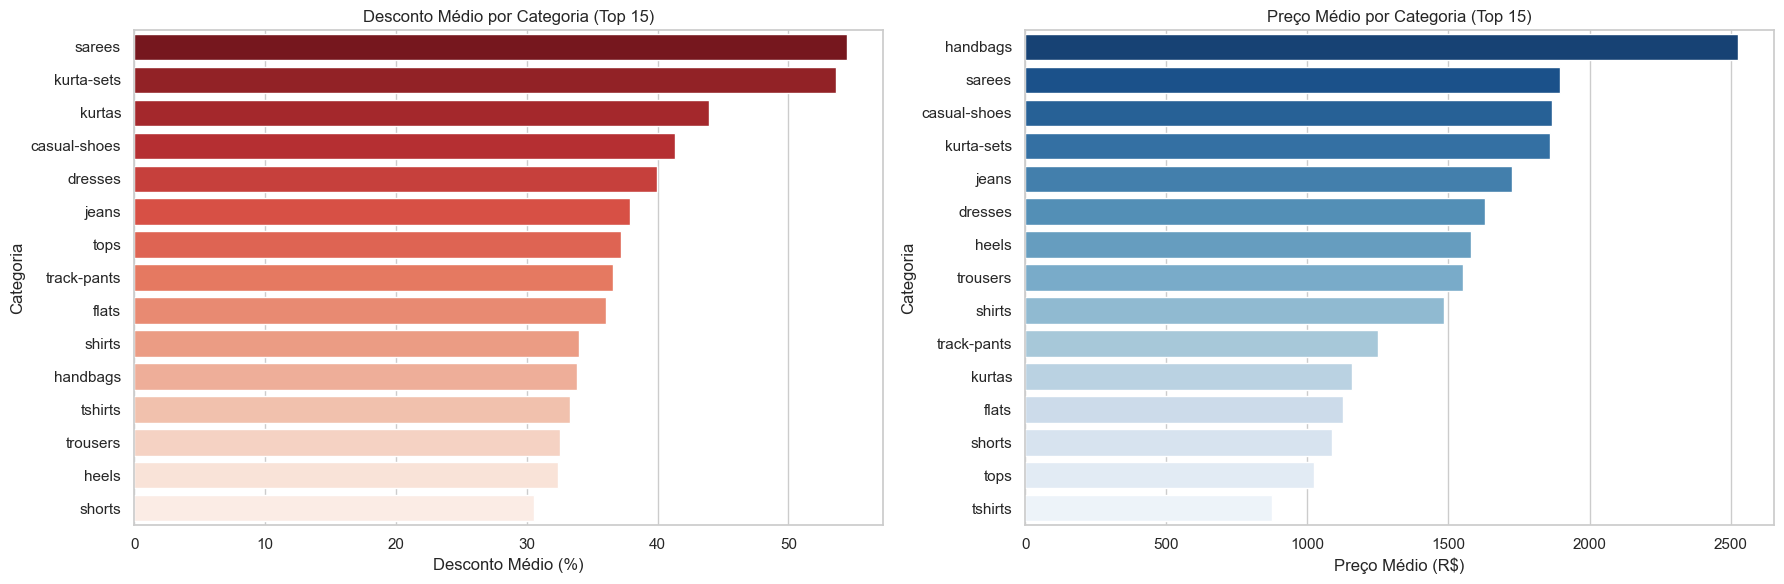

In [31]:
top_cats = category_summary[category_summary['produtos'] >= 200].head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Desconto médio por categoria
top_cats_desc = top_cats.sort_values('desconto_medio', ascending=False)
sns.barplot(data=top_cats_desc.reset_index(), x='desconto_medio', y='product_tag', palette='Reds_r', ax=axes[0])
axes[0].set_title('Desconto Médio por Categoria (Top 15)')
axes[0].set_xlabel('Desconto Médio (%)')
axes[0].set_ylabel('Categoria')

# Preço médio por categoria
top_cats_preco = top_cats.sort_values('preco_medio', ascending=False)
sns.barplot(data=top_cats_preco.reset_index(), x='preco_medio', y='product_tag', palette='Blues_r', ax=axes[1])
axes[1].set_title('Preço Médio por Categoria (Top 15)')
axes[1].set_xlabel('Preço Médio (R$)')
axes[1].set_ylabel('Categoria')

plt.tight_layout()
plt.show()

# 11. Criação de KPIs Globais

KPIs calculados para o dataset completo e também para o subset de produtos avaliados.

In [32]:
kpis = {
    '— PREÇOS —': '',
    'Preço Médio Original': f'R$ {df["marked_price"].mean():,.0f}',
    'Preço Médio com Desconto': f'R$ {df["discounted_price"].mean():,.0f}',
    'Desconto Médio (%)': f'{df["discount_percent"].mean():.1f}%',
    '— RATINGS (apenas avaliados) —': '',
    'Rating Médio Simples': f'{df_avaliados["rating"].mean():.3f}',
    'Rating Médio Ponderado': f'{np.average(df_avaliados["rating"], weights=df_avaliados["rating_count"]):.3f}',
    '% Produtos com Rating >= 4.5': f'{(df_avaliados["rating"] >= 4.5).mean() * 100:.1f}%',
    '— COBERTURA —': '',
    'Total de Produtos': f'{len(df):,}',
    'Produtos Avaliados': f'{len(df_avaliados):,} ({len(df_avaliados)/len(df)*100:.1f}%)',
    'Categorias Únicas': f'{df["product_tag"].nunique()}',
    'Marcas Únicas': f'{df["brand_name"].nunique()}',
}

for k, v in kpis.items():
    if v == '':
        print(f'\n{k}')
    else:
        print(f'  {k}: {v}')


— PREÇOS —
  Preço Médio Original: R$ 2,509
  Preço Médio com Desconto: R$ 1,515
  Desconto Médio (%): 37.3%

— RATINGS (apenas avaliados) —
  Rating Médio Simples: 4.165
  Rating Médio Ponderado: 4.231
  % Produtos com Rating >= 4.5: 24.5%

— COBERTURA —
  Total de Produtos: 168,029
  Produtos Avaliados: 91,349 (54.4%)
  Categorias Únicas: 341
  Marcas Únicas: 3194


# 12. Métrica de Valor Percebido (Feature Engineering)

Criamos um índice para avaliar custo-benefício:

$$\text{Valor Percebido} = \frac{\text{rating} \times \log(\text{rating\_count} + 1)}{\text{preço com desconto}}$$

Essa métrica favorece produtos **bem avaliados**, com **muitas avaliações** e **preço acessível**.

> Calculado apenas para produtos com avaliação para evitar ruído.

In [33]:
df_avaliados = df_avaliados.copy()
df_avaliados['valor_percebido'] = (
    df_avaliados['rating'] * np.log1p(df_avaliados['rating_count'])
) / df_avaliados['discounted_price']

print('Top 10 produtos por Valor Percebido:')
df_avaliados.sort_values('valor_percebido', ascending=False)[
    ['product_name', 'brand_name', 'discounted_price', 'rating', 'rating_count', 'valor_percebido']
].head(10).round(4)

Top 10 produtos por Valor Percebido:


,product_name,brand_name,discounted_price,rating,rating_count,valor_percebido
2672,Nail Pops Nail Polish- 28,ELLE 18,49,4.3,3900,0.7256
152535,Women Pack of 10 Wipes,PEESAFE,61,4.5,2000,0.5608
152528,Women Pack of 10 Wipes,PEESAFE,61,4.5,2000,0.5608
20293,Unisex Sandalwood Soap,Khadi Natural,64,4.5,2300,0.5443
142437,Nail Colour Remover 27 ml,Lakme,83,4.6,17300,0.5408
76467,Beauty Accessory,Lakme,65,4.5,2100,0.5296
44231,Unisex Pure Lavender Soap,Khadi Natural,64,4.4,1800,0.5154
1179,Unisex Ayurvedic Almond Soap,Khadi Natural,64,4.5,1100,0.4925
54295,Unisex Neem-Tulsi Soap,Khadi Natural,64,4.5,1100,0.4925
115207,Kajal - Black,Lakme,72,4.2,4600,0.4920


# 13. Produtos Supervalorizados vs Subvalorizados

Identificamos extremos do portfólio:
- **Supervalorizados:** preço no top 25% e rating < 3.5
- **Subvalorizados:** preço no bottom 25% e rating >= 4.5 com volume de avaliações

Análise feita **apenas em produtos avaliados** para garantir consistência.

In [34]:
q75 = df_avaliados['discounted_price'].quantile(0.75)
q25 = df_avaliados['discounted_price'].quantile(0.25)

df_avaliados['flag_supervalorizado'] = (
    (df_avaliados['discounted_price'] > q75) & (df_avaliados['rating'] < 3.5)
)
df_avaliados['flag_subvalorizado'] = (
    (df_avaliados['discounted_price'] < q25) &
    (df_avaliados['rating'] >= 4.5) &
    (df_avaliados['rating_count'] >= df_avaliados['rating_count'].median())
)

n_super = df_avaliados['flag_supervalorizado'].sum()
n_sub = df_avaliados['flag_subvalorizado'].sum()
print(f'Produtos supervalorizados: {n_super:,} ({n_super/len(df_avaliados)*100:.1f}%)')
print(f'Produtos subvalorizados: {n_sub:,} ({n_sub/len(df_avaliados)*100:.1f}%)')

print('\nAmostra de supervalorizados:')
df_avaliados[df_avaliados['flag_supervalorizado']][[
    'product_name', 'brand_name', 'discounted_price', 'rating', 'rating_count'
]].head(5)

Produtos supervalorizados: 1,576 (1.7%)
Produtos subvalorizados: 2,338 (2.6%)

Amostra de supervalorizados:


,product_name,brand_name,discounted_price,rating,rating_count
45,Women Relaxed Fit High-Rise Jeans,ONLY,2959,1.3,3
59,Women Relaxed Fit High-Rise Jeans,ONLY,2959,1.3,3
81,Men Slim Fit Jeans,Flying Machine,1754,3.1,7
324,EcoVero Drop-Waist Dress,MANGO,1644,3.1,18
395,Men Stainless Steel Straps Watch,Tommy Hilfiger,3896,2.2,9


# 14. Mapa de Calor — Correlações Numéricas

Visualização da correlação entre todas as variáveis numéricas do dataset para orientar análises futuras.

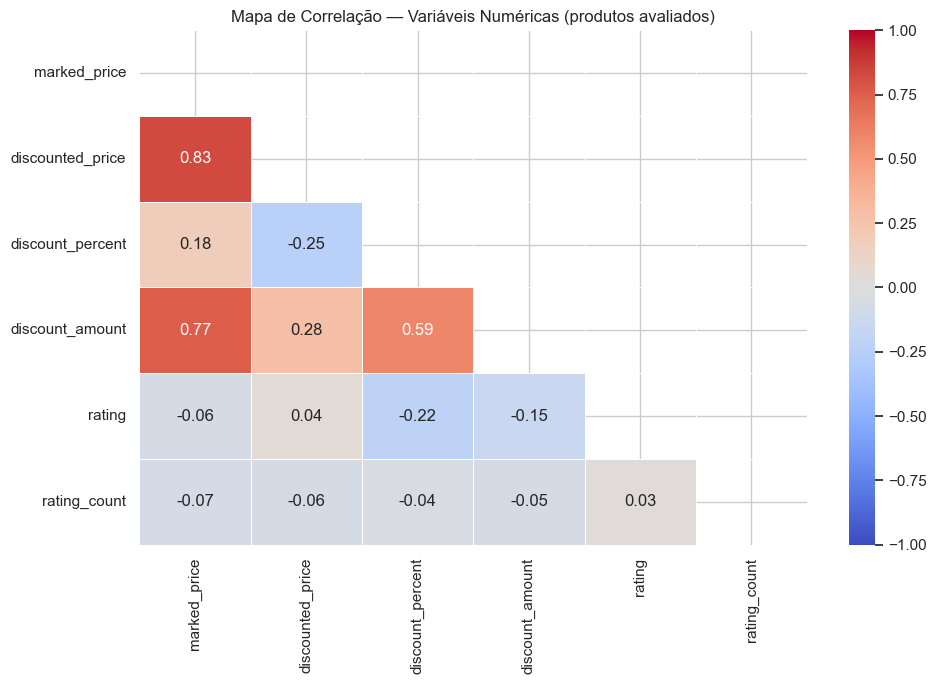

In [35]:
numeric_cols = ['marked_price', 'discounted_price', 'discount_percent',
                'discount_amount', 'rating', 'rating_count']

corr_matrix = df_avaliados[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5
)
ax.set_title('Mapa de Correlação — Variáveis Numéricas (produtos avaliados)')
plt.tight_layout()
plt.show()

# 15. Conclusões Analíticas

**Principais achados desta análise exploratória:**

1. **~45% dos produtos não têm avaliações** — dado crítico para qualquer análise de rating.
2. **Desconto não garante boa avaliação** — correlação fraca ou negativa entre desconto e rating.
3. **Distribuição de preços é extremamente assimétrica** — com cauda longa de produtos premium.
4. **Rating médio ponderado é mais confiável** que o simples para comparar marcas.
5. **Existem produtos claramente supervalorizados** — caros e mal avaliados — e oportunidades subvalorizadas.

**Este notebook alimenta diretamente:**
- Criação de medidas DAX no Power BI
- Construção de dashboards executivos
- Base para a análise avançada com ML (analiseAvancada.ipynb)